# LAB 02: THỰC HÀNH IMAGE FILTER

Khai báo thư viện ảnh

In [2]:
import cv2
import matplotlib.pyplot as NguyenHuynhAnhTu

Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu

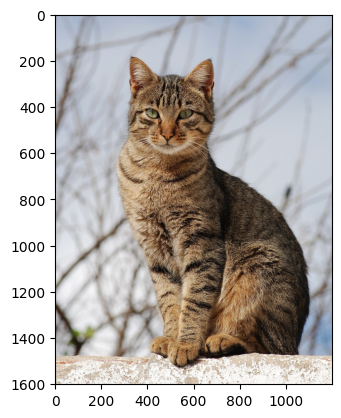

In [ ]:
img = cv2.imread('hinh1.png')
img = img[:,:,::-1]
NguyenHuynhAnhTu.imshow(img)

1. Sử dụng boxFilter:
cv2.blur() hoặc cv2.boxFilter() để làm mờ ảnh (sử dụng nhiều thông số filter khác nhau), biểu diễn ảnh gốc và ảnh làm mờ cùng nhau để kiểm chứng.

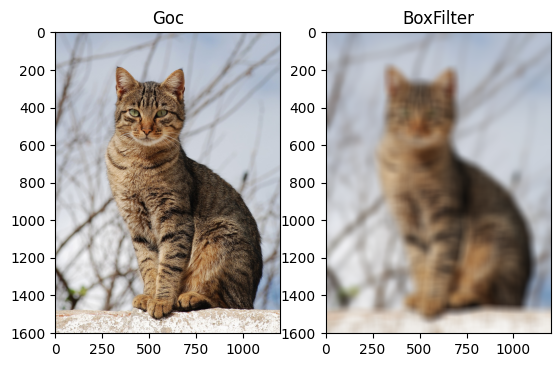

In [4]:
img2 = cv2.boxFilter(img,-1,(51,51))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(img)
NguyenHuynhAnhTu.title("Goc")
NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(img2)
NguyenHuynhAnhTu.title("BoxFilter")
NguyenHuynhAnhTu.show()

2. Sử dụng Gaussian Filter # Lưu ý: kích thước bộ lọc là số lẻ.

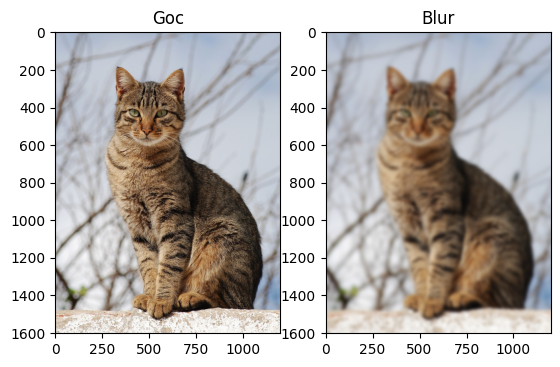

In [5]:
img_blur = cv2.GaussianBlur(img, (51, 51), 0)
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(img)
NguyenHuynhAnhTu.title("Goc")
NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(img_blur)
NguyenHuynhAnhTu.title("Blur")
NguyenHuynhAnhTu.show()

3. Sử dụng Median Filter 

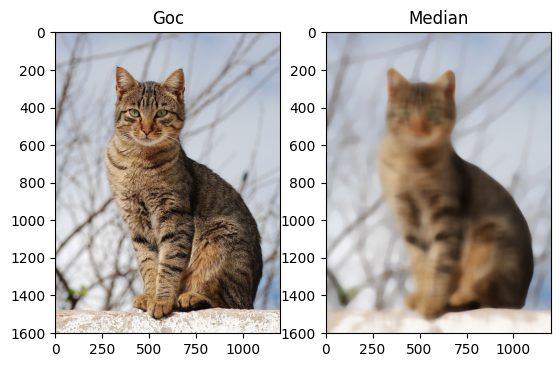

In [6]:
img_median = cv2.medianBlur(img, 51)
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(img)
NguyenHuynhAnhTu.title("Goc")
NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(img_median)
NguyenHuynhAnhTu.title("Median")
NguyenHuynhAnhTu.show()

4. Kiểm tra lại các bộ lọc trên với hai hình ảnh pepper noise 

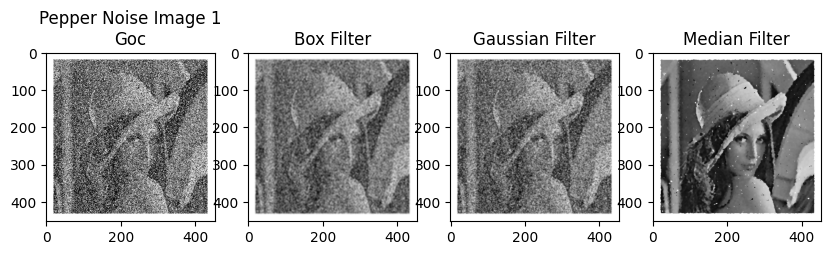

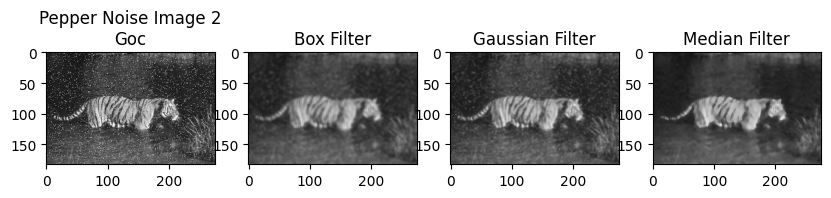

In [ ]:
img1 = cv2.imread("hinh2.png")
img2 = cv2.imread("hinh3.png")

def show_filters(img, title):
    # Box Filter
    box = cv2.boxFilter(img, -1, (5, 5))
    
    # Gaussian Filter
    gaussian = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Median Filter
    median = cv2.medianBlur(img, 5)
    
    NguyenHuynhAnhTu.figure(figsize=(10, 10))
    NguyenHuynhAnhTu.subplot(1, 4, 1)
    NguyenHuynhAnhTu.imshow(img, cmap='gray')
    NguyenHuynhAnhTu.title(f"{title}\nGoc")
    
    NguyenHuynhAnhTu.subplot(1, 4, 2)
    NguyenHuynhAnhTu.imshow(box, cmap='gray')
    NguyenHuynhAnhTu.title("Box Filter")
    
    NguyenHuynhAnhTu.subplot(1, 4, 3)
    NguyenHuynhAnhTu.imshow(gaussian, cmap='gray')
    NguyenHuynhAnhTu.title("Gaussian Filter")
    
    NguyenHuynhAnhTu.subplot(1, 4, 4)
    NguyenHuynhAnhTu.imshow(median, cmap='gray')
    NguyenHuynhAnhTu.title("Median Filter")
    
    NguyenHuynhAnhTu.show()

# Áp dụng cho 2 ảnh
show_filters(img1, "Pepper Noise Image 1")
show_filters(img2, "Pepper Noise Image 2")


5. Có nhận xét gì về các kích thước filter

Kích thước filter càng lớn thì khả năng làm mờ và khử nhiễu càng mạnh, nhưng đồng thời làm mất chi tiết ảnh. Do đó cần lựa chọn kích thước filter phù hợp để cân bằng giữa giảm nhiễu và bảo toàn thông tin ảnh.


6. Thực hành với Cân bằng sáng - equalizeHist, để cân bằng sáng, trước hết ta chuyển ảnh trắng đen (nếu có) sang ảnh màu. 

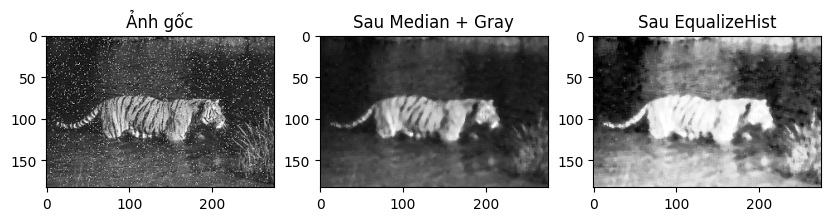

In [ ]:
img = cv2.imread('hinh3.png')

blur = cv2.medianBlur(img, 5)
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
# Cân bằng sáng
equalized = cv2.equalizeHist(gray)

NguyenHuynhAnhTu.figure(figsize=(10,4))
NguyenHuynhAnhTu.subplot(1,3,1)
NguyenHuynhAnhTu.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title("Ảnh gốc")

NguyenHuynhAnhTu.subplot(1,3,2)
NguyenHuynhAnhTu.imshow(gray, cmap='gray')
NguyenHuynhAnhTu.title("Sau Median + Gray")

NguyenHuynhAnhTu.subplot(1,3,3)
NguyenHuynhAnhTu.imshow(equalized, cmap='gray')
NguyenHuynhAnhTu.title("Sau EqualizeHist")

NguyenHuynhAnhTu.show()

7. Bài tập trên lớp lý thuyết: FILTER bằng các phép toán số học và logic
Given two images as follow (with different sizes: 193x157 and 194x160) 


a. Crop two images to size 190x155

In [ ]:
h = cv2.imread('hinh4.png')
w = cv2.imread('hinh5.png')
img1_crop = h[:155,1:191]
img2_crop = w[:155,:190]
print(img1.shape, img2.shape)


(157, 193, 3) (160, 194, 3)


b. Transform images to negative ones.

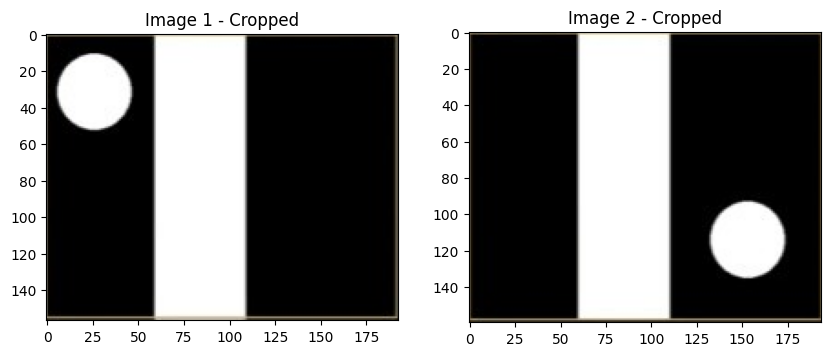

In [22]:
inv_img1 = cv2.bitwise_not(img1)
inv_img2 = cv2.bitwise_not(img2)
NguyenHuynhAnhTu.figure(figsize=(10,10))
NguyenHuynhAnhTu.subplot(1,2,1)
NguyenHuynhAnhTu.imshow(cv2.cvtColor(inv_img1, cv2.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title("Image 1 - Cropped")
NguyenHuynhAnhTu.subplot(1,2,2)
NguyenHuynhAnhTu.imshow(cv2.cvtColor(inv_img2, cv2.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title("Image 2 - Cropped")

NguyenHuynhAnhTu.show()

c. Process to have an image which has only the “ball

In [23]:
ball = cv2.absdiff(inv_img1, inv_img2)
NguyenHuynhAnhTu.figure(figsize=(10,10))
NguyenHuynhAnhTu.imshow(cv2.cvtColor(ball, cv2.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title("Extracted Ball (Before Noise Removal)")
NguyenHuynhAnhTu.show()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\arithm.cpp:665: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'cv::arithm_op'
